# 🎬 Netflix Data Analysis

## Objective

The objective of this project is to analyze Netflix's Movies and TV Shows dataset to discover trends, understand content distribution, and generate business insights using Python.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use("ggplot")

# Load the dataset
df = pd.read_csv("../data/netflix_titles.csv")

# Display the first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 📊 Dataset Overview

The dataset contains information about Netflix Movies and TV Shows, including:

- Title
- Director
- Cast
- Country
- Release Year
- Date Added
- Rating
- Duration
- Genre

In [16]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## 🧹 Data Cleaning

Before analysis, we examine the dataset for missing values, duplicate records, and data quality issues.

In [17]:
# Check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## 🧹 Data Cleaning

In this section, we inspect the dataset, identify missing values, and prepare the data for analysis.

In [18]:
# Statistical summary
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


# 📊 Exploratory Data Analysis (EDA)

In this notebook, we analyze the Netflix Movies and TV Shows dataset to understand its content distribution, trends, ratings, genres, and countries.

In [19]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


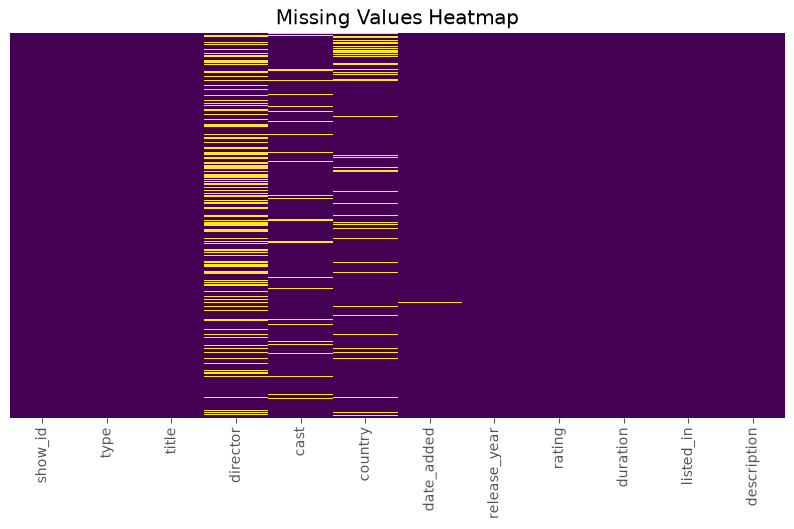

In [20]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

## 📊 Data Visualization

We visualize the data to understand content trends, ratings, countries, genres, and release patterns.

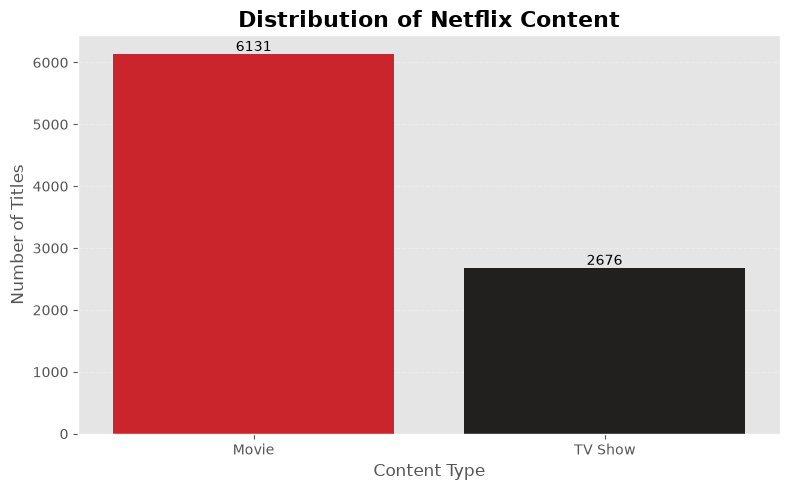

In [29]:
plt.figure(figsize=(8,5))

colors = ["#E50914", "#221F1F"]

ax = sns.countplot(
    data=df,
    x="type",
    hue="type",
    palette=colors,
    legend=False
)

plt.title(
    "Distribution of Netflix Content",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/movies_vs_tvshows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Observation

- Movies represent the majority of Netflix's content library.
- TV Shows make up a smaller but steadily growing portion of the platform.
- This suggests Netflix has historically focused more on movies while gradually expanding its TV content.

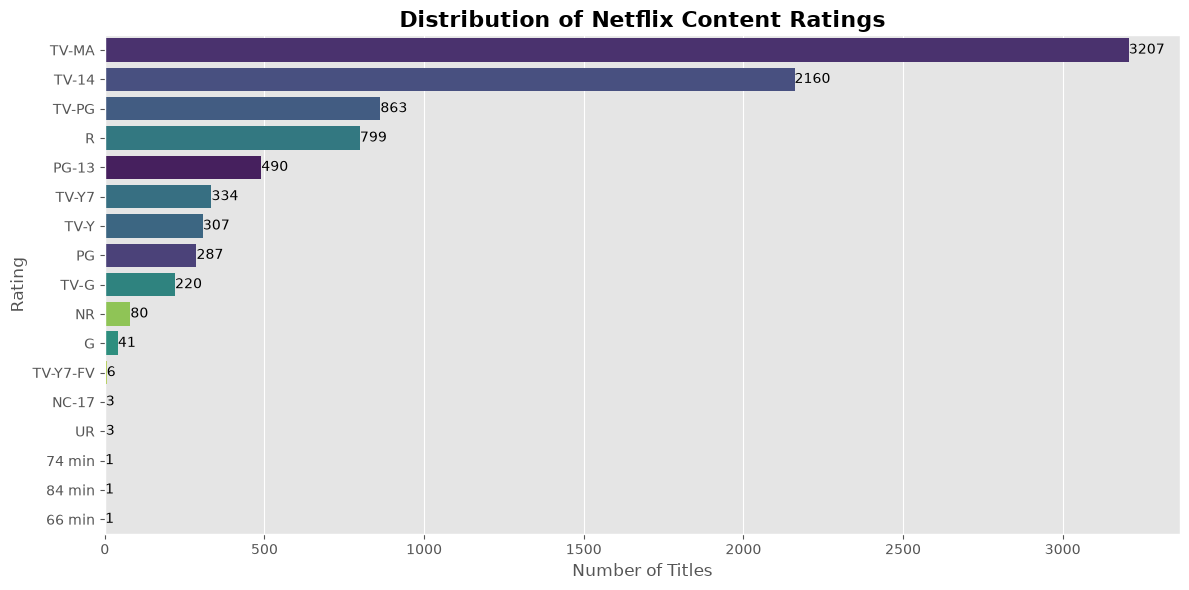

In [30]:
plt.figure(figsize=(12,6))

rating_order = df["rating"].value_counts().index

ax = sns.countplot(
    data=df,
    y="rating",
    order=rating_order,
    hue="rating",
    palette="viridis",
    legend=False
)

plt.title(
    "Distribution of Netflix Content Ratings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Rating")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Observation

- TV-MA is the most common content rating.
- Netflix offers a significant amount of mature-rated content.
- Family-oriented content represents a smaller share of the overall catalog.

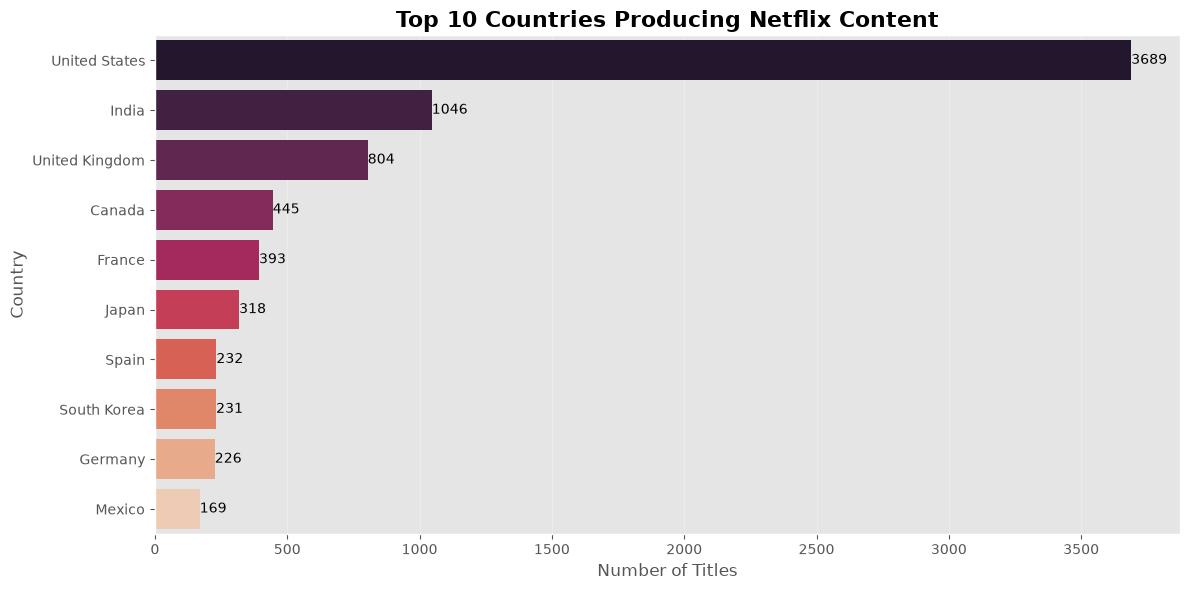

In [31]:
# Top 10 Countries Producing Netflix Content

country = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_countries = country.value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="rocket",
    legend=False
)

plt.title(
    "Top 10 Countries Producing Netflix Content",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/top_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Observation

- The United States has the largest number of titles on Netflix.
- India ranks among the top content-producing countries, reflecting Netflix's investment in regional entertainment.
- The global distribution of content demonstrates Netflix's strategy of serving diverse international audiences.

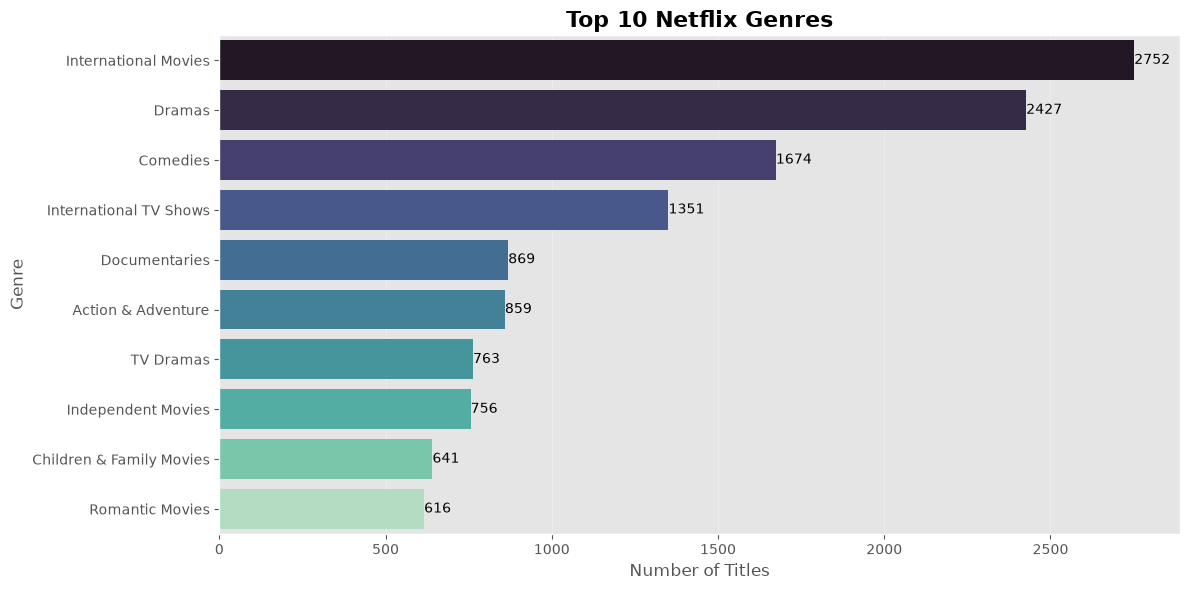

In [32]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="mako",
    legend=False
)

plt.title(
    "Top 10 Netflix Genres",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Genre")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/top_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Observation

- International Movies is the most popular genre.
- Dramas and Comedies also contribute significantly to Netflix's catalog.
- Netflix offers a diverse mix of genres to cater to audiences across different regions and preferences.

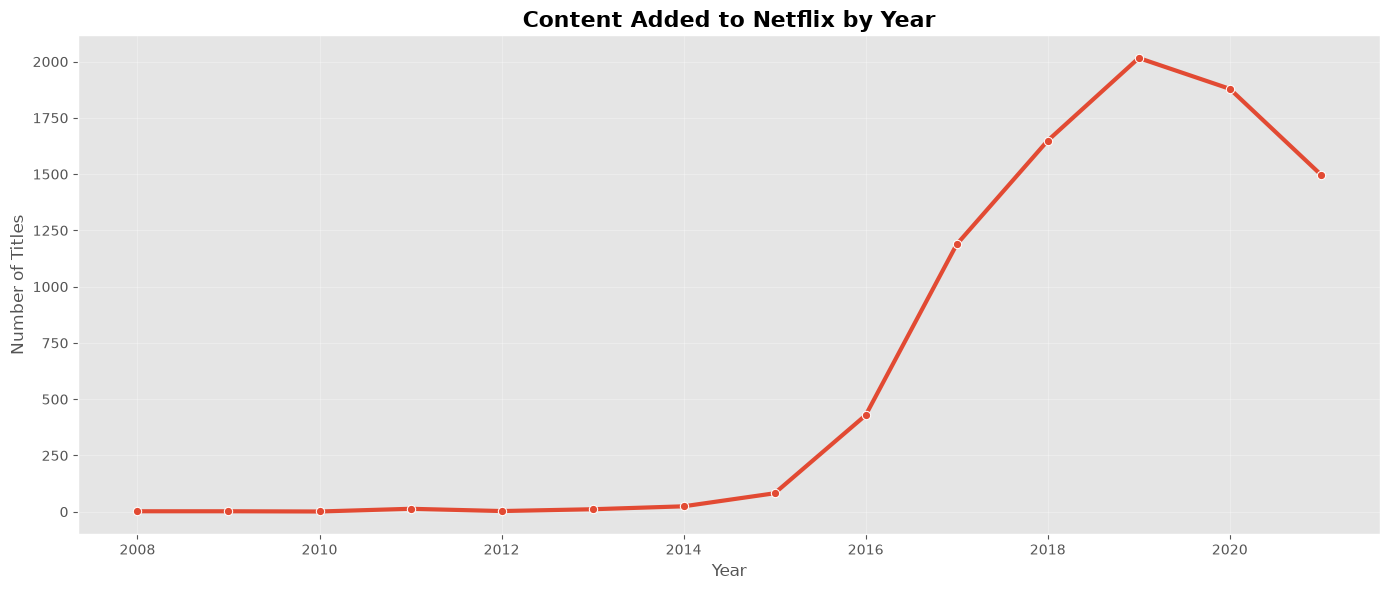

In [33]:
content_by_year = (
    df["year_added"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,6))

ax = sns.lineplot(
    x=content_by_year.index,
    y=content_by_year.values,
    marker="o",
    linewidth=3
)

plt.title(
    "Content Added to Netflix by Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/content_added_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📌 Business Recommendations

### 1. Increase Investment in International Content

International Movies and TV Shows attract a diverse global audience. Continued investment in localized content can improve subscriber growth in emerging markets.

---

### 2. Expand Original Series Production

Although Movies dominate the catalog, high-quality original TV Shows can increase user engagement and long-term subscriber retention.

---

### 3. Maintain a Balanced Content Library

While mature-rated content is highly represented, expanding family-friendly programming can help reach a broader audience across age groups.

---

### 4. Use Data-Driven Content Strategy

Analyze viewing patterns and audience preferences to guide future investments in genres, languages, and regions.

---

### 5. Improve Metadata Quality

Address missing information for directors, cast members, and countries to improve search functionality and recommendation systems.